### Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [1]:
!nvidia-smi

Fri Oct 10 14:26:15 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**NOTE:** To make it easier for us to manage datasets, images and models we create a `HOME` constant.

In [7]:
import os
HOME = os.getcwd()
print(HOME)

/content


## Install YOLO11 via Ultralytics

In [4]:
%pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.3.209 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 40.1/112.6 GB disk)


**NOTE:** When training YOLO11, make sure your data is located in `{HOME}/datasets`. If you'd like to change the default location of the data you want to use for fine-tuning, you can do so through Ultralytics' `settings.json`. When downloading data from [Roboflow Universe](https://universe.roboflow.com/), use the YOLOv8 format.

In [8]:
!mkdir {HOME}/drive/MyDrive/MiniProject/datasets
%cd {HOME}/drive/MyDrive/MiniProject/datasets

!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="c2z37Ayo0rWmUnWG9EI2")
project = rf.workspace("miniproject-lifu2").project("drowsinessdetectionyolov8-test2-qxepk")
version = project.version(4)
dataset = version.download("yolov11")



/content/drive/MyDrive/MiniProject/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to DrowsinessDetectionYolov8-Test2-4 in yolov11:: 100%|██████████| 5246/5246 [00:42<00:00, 123.53it/s]


**NOTE:** Make sure to run commands below to make dataset work with YOLO11 training.

In [9]:
#%cd {HOME}/drive/MyDrive/MiniProject/datasets
!sed -i '$d' {dataset.location}/data.yaml   # Delete the last line
!sed -i '$d' {dataset.location}/data.yaml   # Delete the second-to-last line
!sed -i '$d' {dataset.location}/data.yaml   # Delete the third-to-last line

!echo 'test: ../test/images' >> {dataset.location}/data.yaml
!echo 'train: ../train/images' >> {dataset.location}/data.yaml
!echo 'val: ../valid/images' >> {dataset.location}/data.yaml

## Custom Training

In [10]:
%cd {HOME}/drive/MyDrive/MiniProject

!yolo task=detect mode=train model=yolo11s.pt data={dataset.location}/data.yaml epochs=50 imgsz=640 plots=True

/content/drive/MyDrive/MiniProject
Ultralytics 8.3.209 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/MiniProject/datasets/DrowsinessDetectionYolov8-Test2-4/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimi

**NOTE:** The results of the completed training are saved in `{HOME}/runs/detect/train/`. Let's examine them.

In [11]:
!ls {HOME}/drive/MyDrive/MiniProject/runs/detect/train/

args.yaml			 results.csv	      val_batch0_labels.jpg
BoxF1_curve.png			 results.png	      val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg     val_batch1_labels.jpg
BoxPR_curve.png			 train_batch1.jpg     val_batch1_pred.jpg
BoxR_curve.png			 train_batch2.jpg     val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch3880.jpg  val_batch2_pred.jpg
confusion_matrix.png		 train_batch3881.jpg  weights
labels.jpg			 train_batch3882.jpg


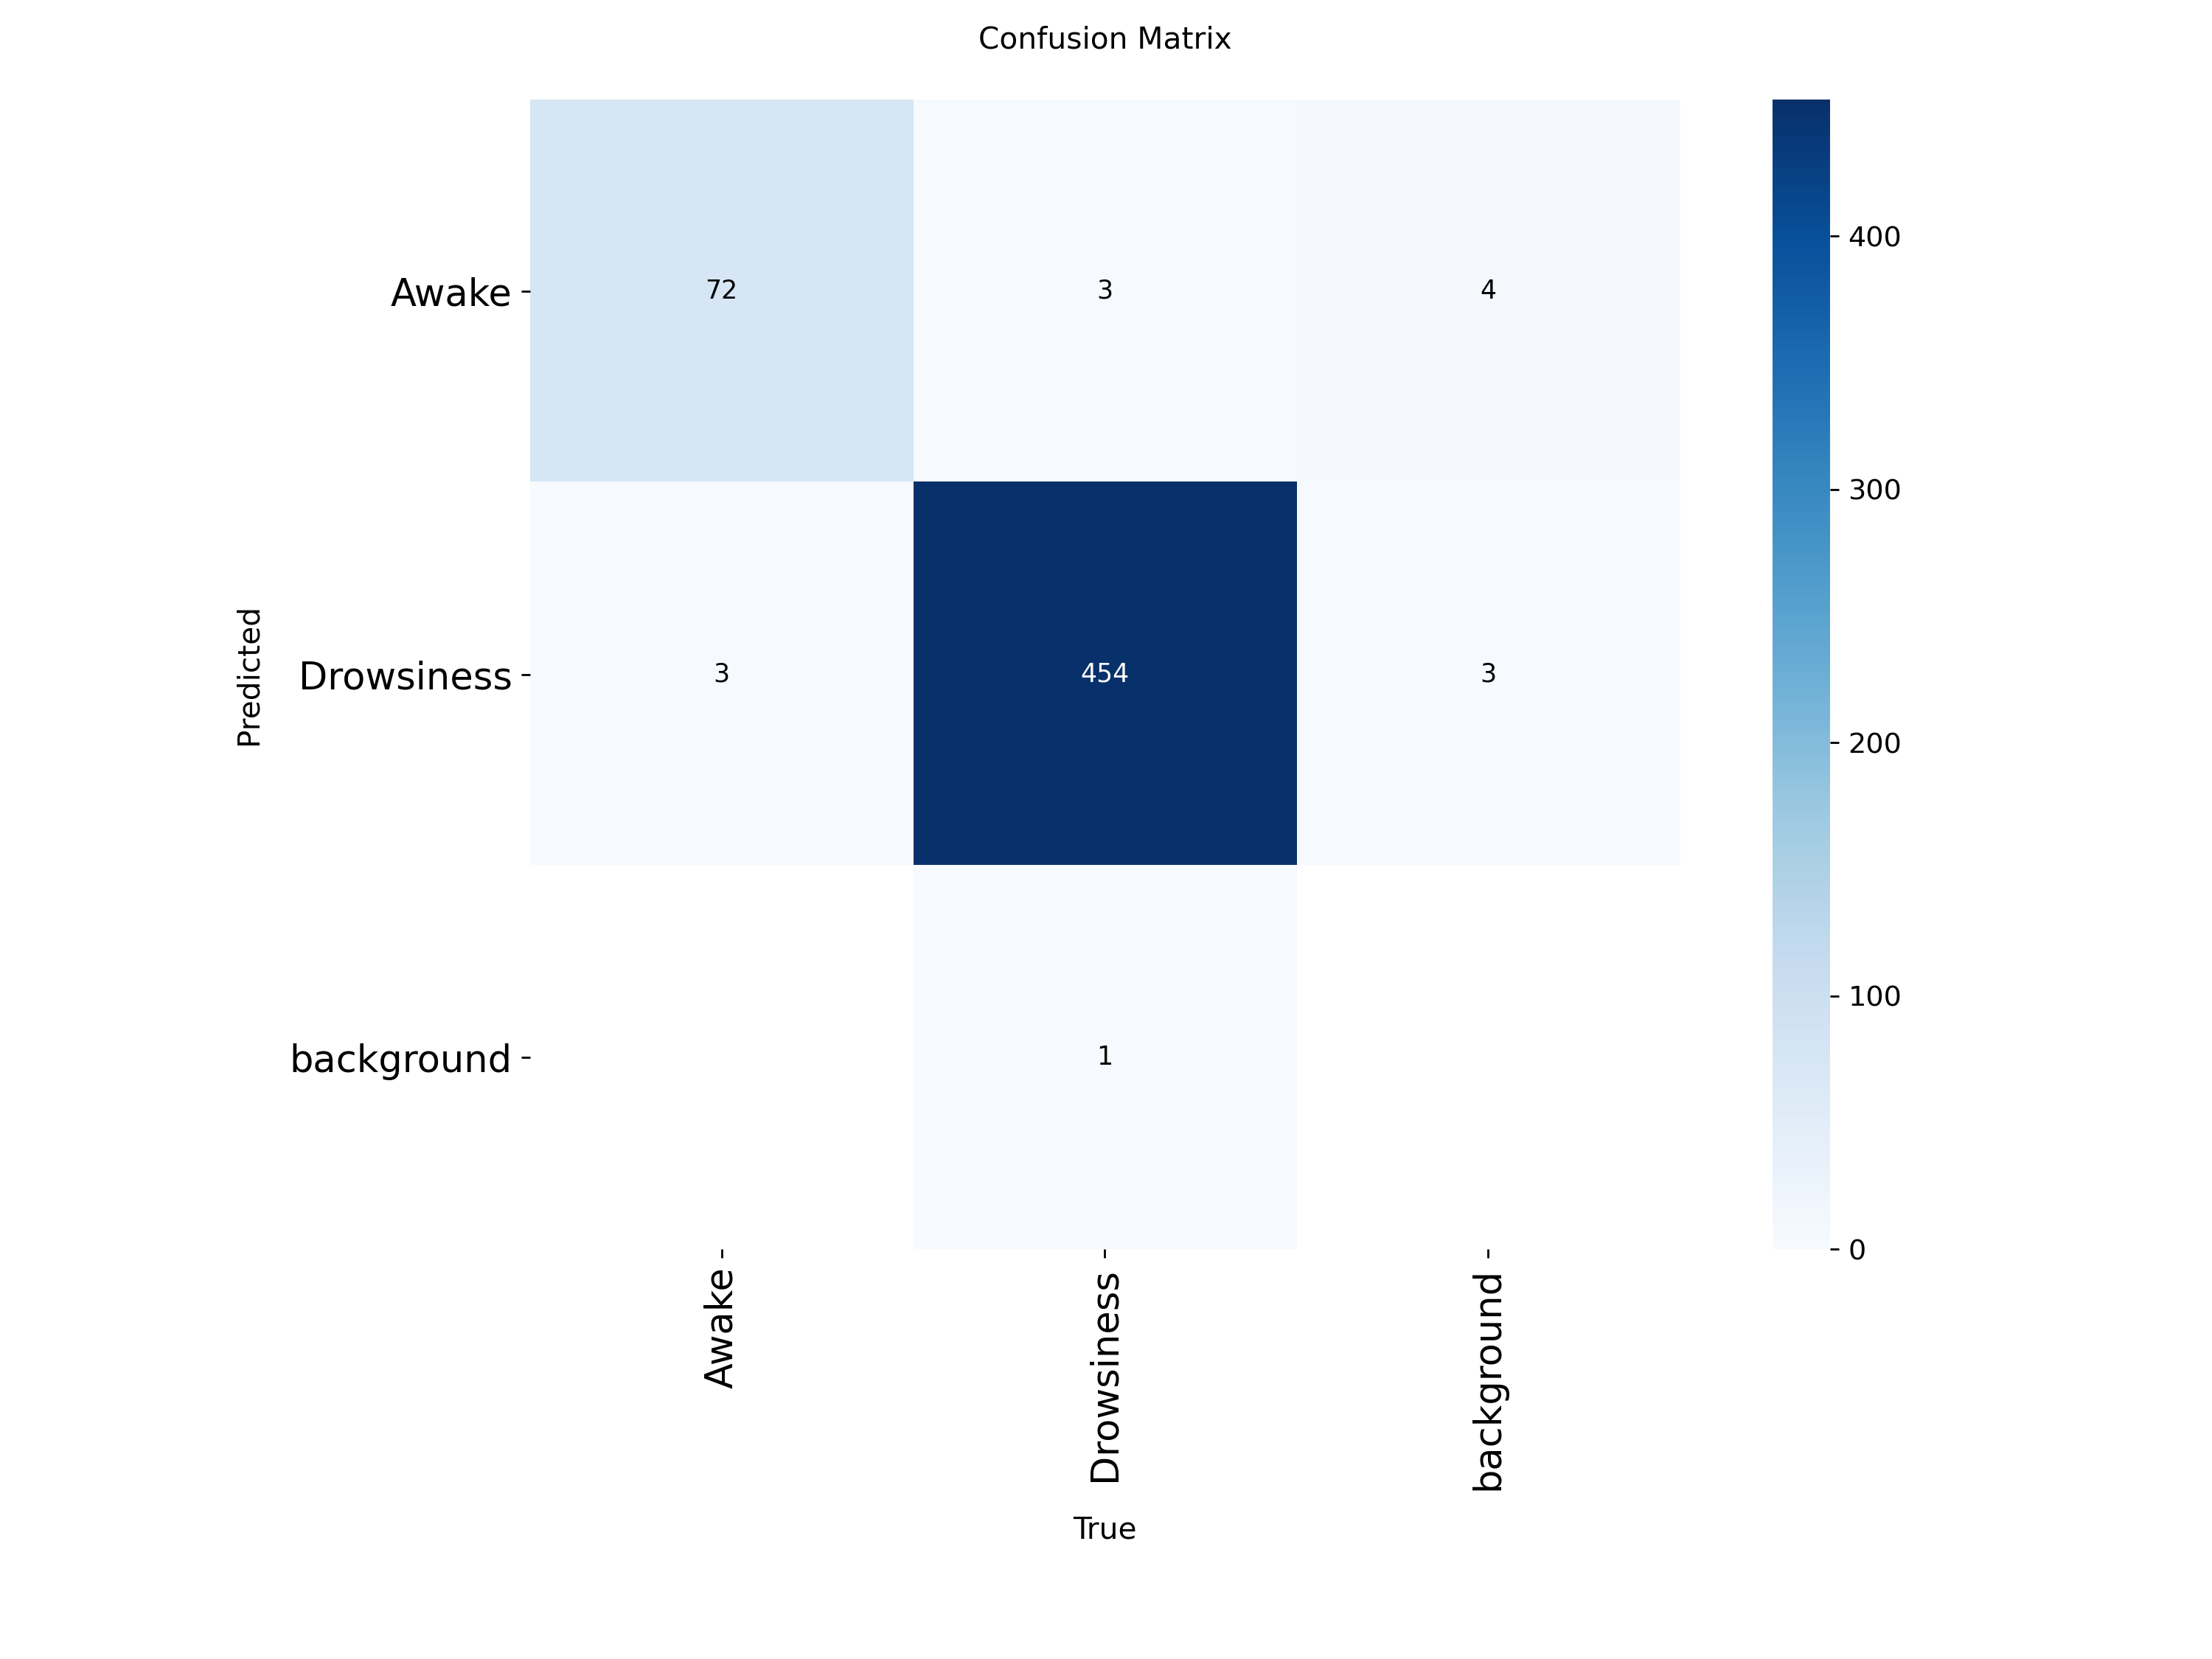

In [12]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/drive/MyDrive/MiniProject/runs/detect/train/confusion_matrix.png', width=600)

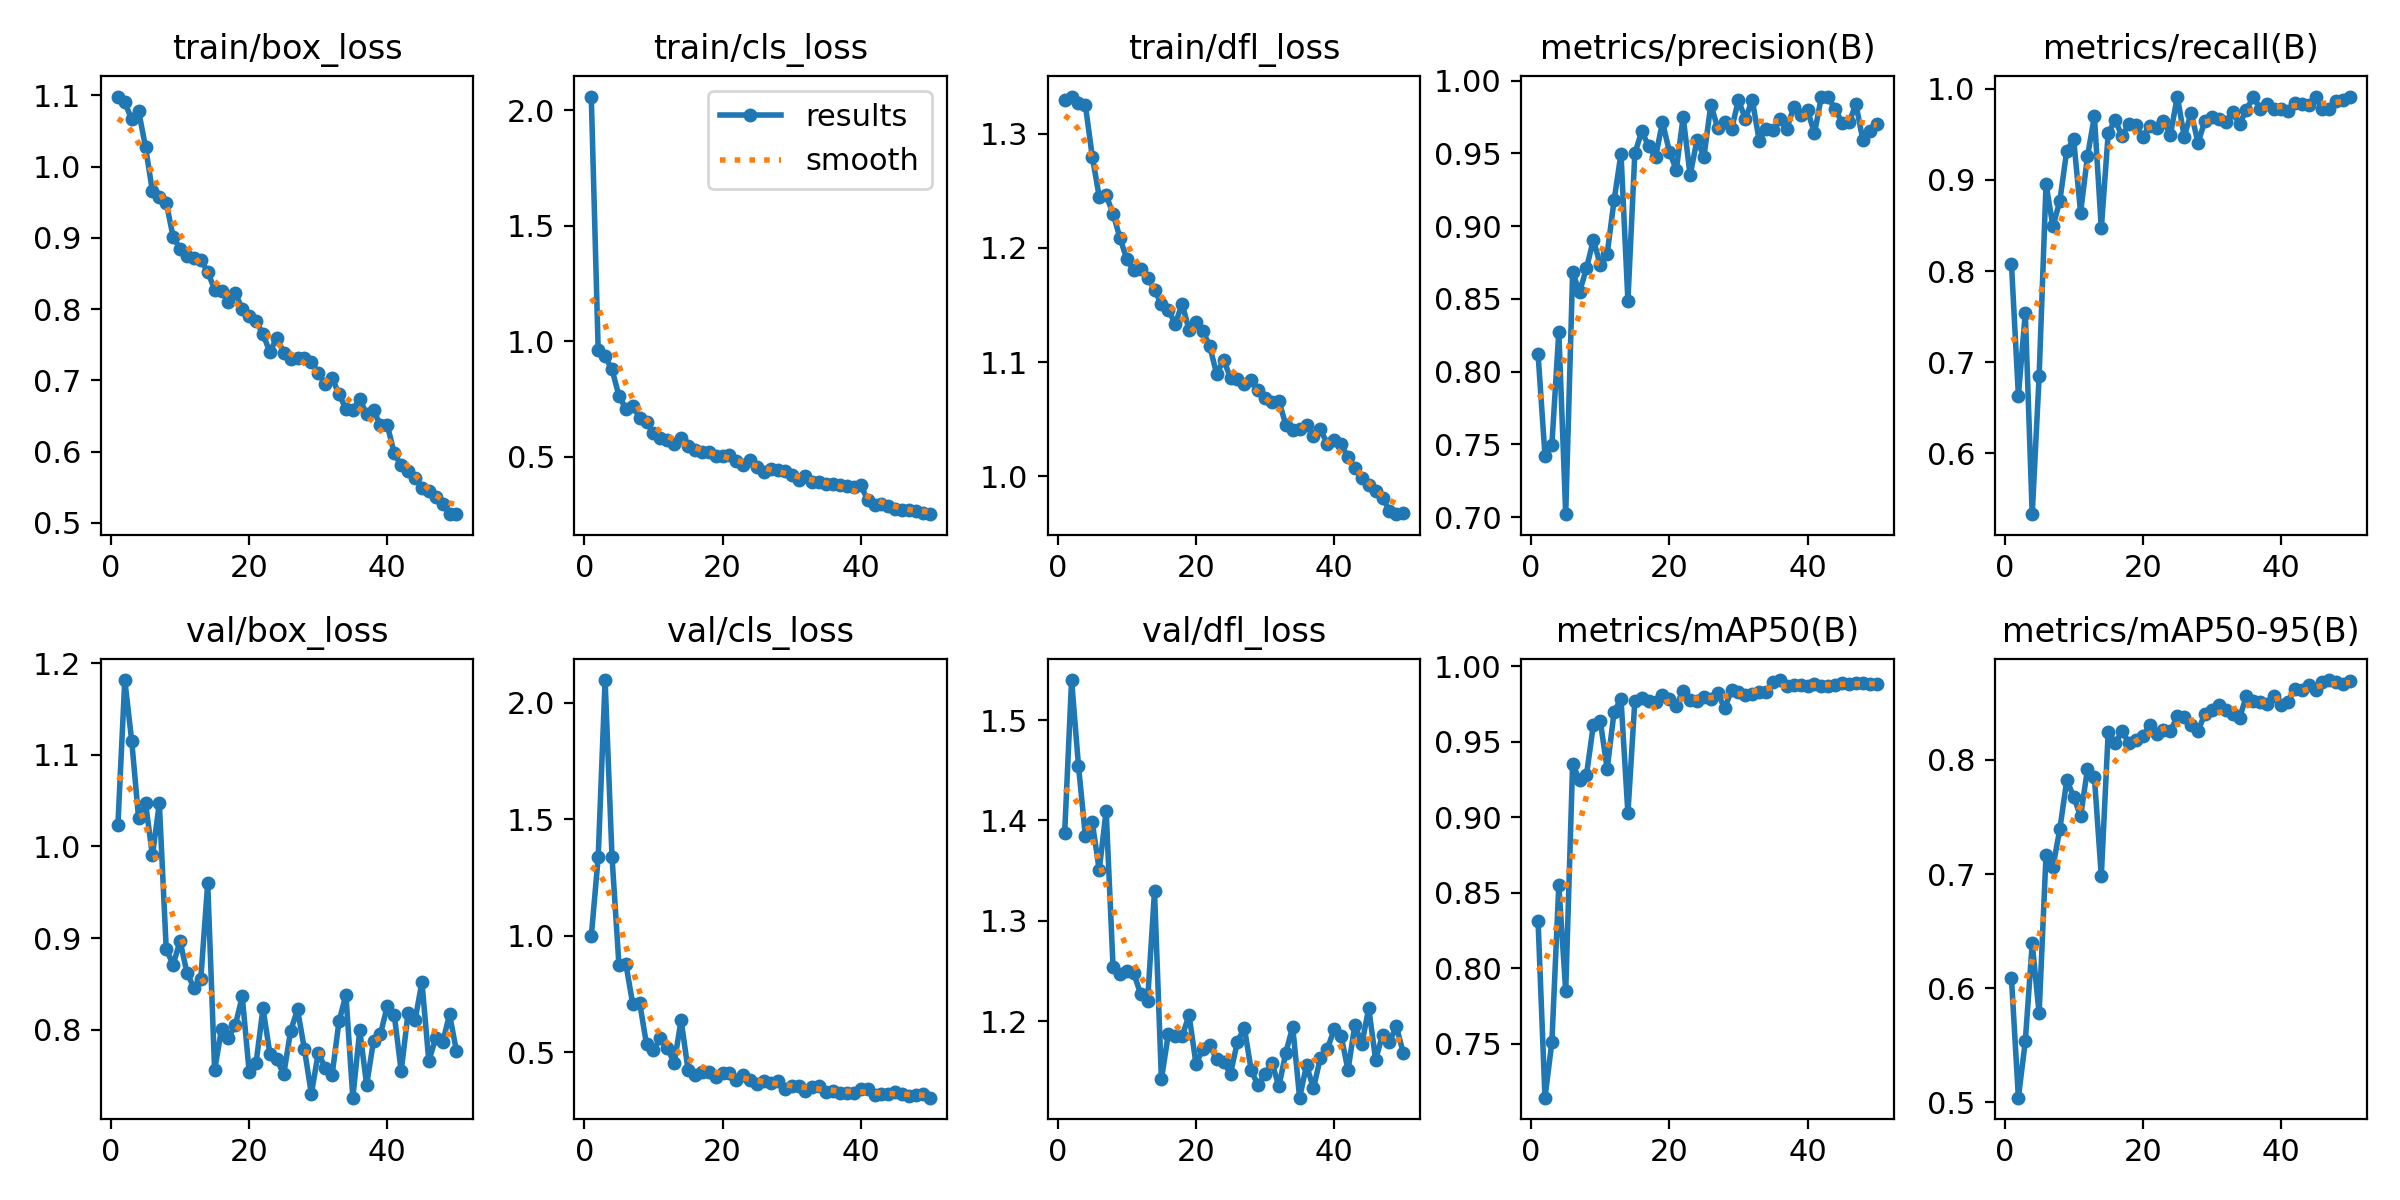

In [13]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/drive/MyDrive/MiniProject/runs/detect/train/results.png', width=600)

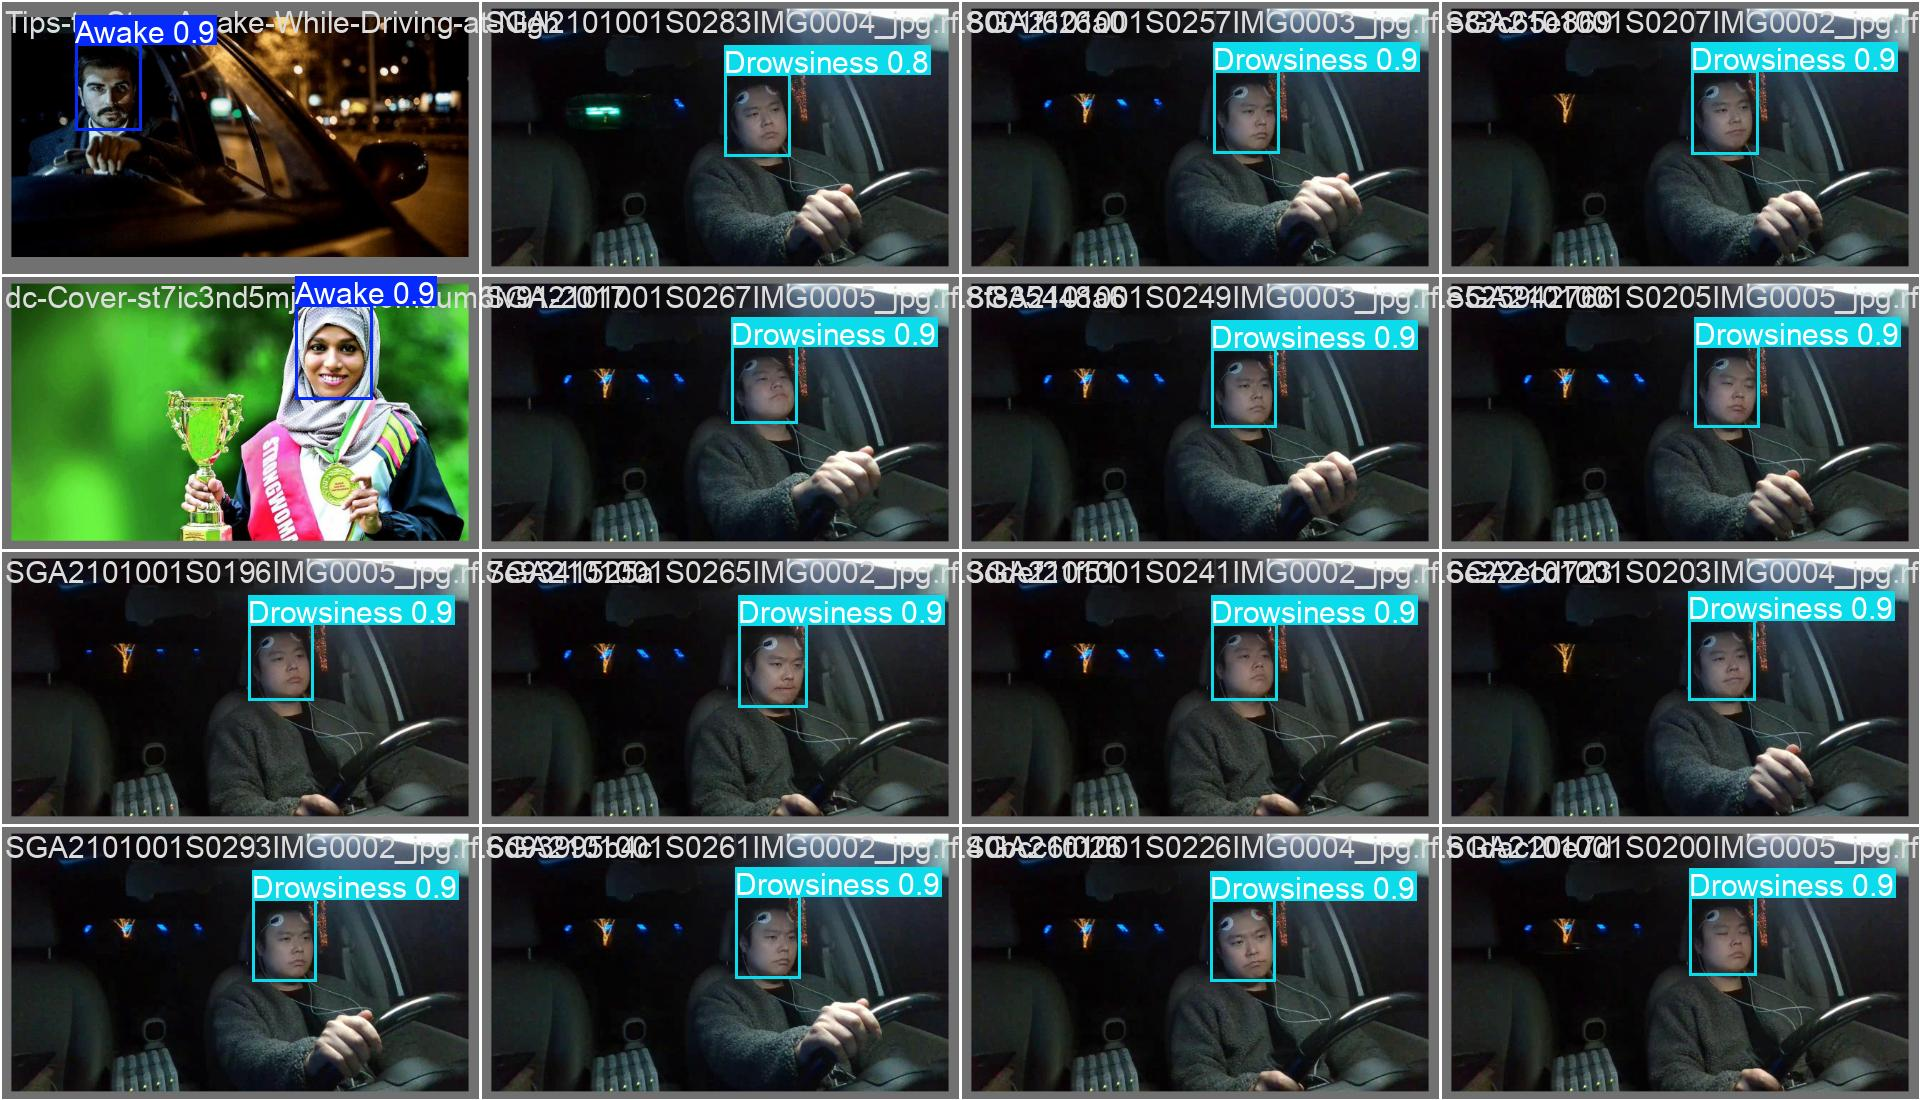

In [14]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/drive/MyDrive/MiniProject/runs/detect/train/val_batch0_pred.jpg', width=600)

## Validate fine-tuned model

In [15]:
!yolo task=detect mode=val model={HOME}/drive/MyDrive/MiniProject/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.3.209 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 100 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.2 ms, read: 57.2±8.0 MB/s, size: 119.9 KB)
val: Scanning /content/drive/MyDrive/MiniProject/datasets/DrowsinessDetectionYolov8-Test2-4/valid/labels.cache... 529 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 529/529 7.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 34/34 3.3it/s 10.4s
                   all        529        533      0.984      0.978      0.989      0.871
                 Awake         74         75      0.974      0.973      0.986      0.919
            Drowsiness        455        458      0.993      0.982      0.992      0.822
Speed: 0.6ms preprocess, 6.9ms inference, 0.0ms loss, 3.0ms postprocess per image
Results saved to /content/drive/MyDrive/MiniProject/runs/detect/val
💡 Learn more at

## Inference with custom model

In [16]:
!yolo task=detect mode=predict model={HOME}/drive/MyDrive/MiniProject/runs/detect/train/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

Ultralytics 8.3.209 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 100 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs

image 1/539 /content/drive/MyDrive/MiniProject/datasets/DrowsinessDetectionYolov8-Test2-4/test/images/Drowsy_face_1_png.rf.f644b57b15c5eac993943c16b320f2c5.jpg: 544x640 1 Drowsiness, 53.6ms
image 2/539 /content/drive/MyDrive/MiniProject/datasets/DrowsinessDetectionYolov8-Test2-4/test/images/Eyes-Closed-2_mp4-11_jpg.rf.7745767bda0b0725ad35aad4f270f702.jpg: 480x640 1 Drowsiness, 52.2ms
image 3/539 /content/drive/MyDrive/MiniProject/datasets/DrowsinessDetectionYolov8-Test2-4/test/images/Eyes-Closed-2_mp4-28_jpg.rf.290f8be318c33dad64cf429335d567a1.jpg: 480x640 1 Drowsiness, 12.3ms
image 4/539 /content/drive/MyDrive/MiniProject/datasets/DrowsinessDetectionYolov8-Test2-4/test/images/Eyes-Closed-2_mp4-48_jpg.rf.739fec18df38d21fcb5dfd7560d080be.jpg: 480x640 1 Drowsiness, 12.3ms
image 5/539 /content/drive/MyDrive/MiniProject/data

**NOTE:** Let's take a look at few results.

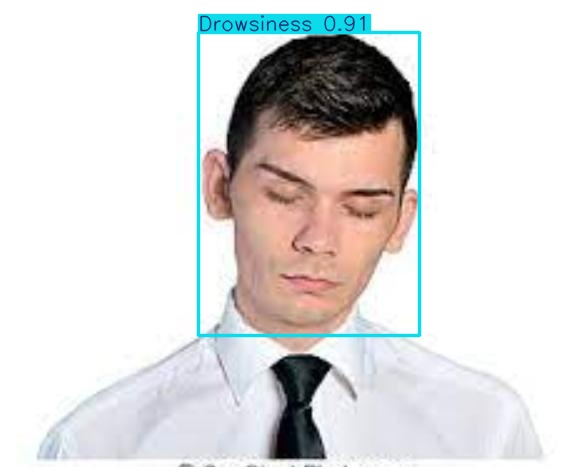

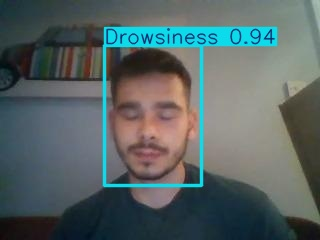

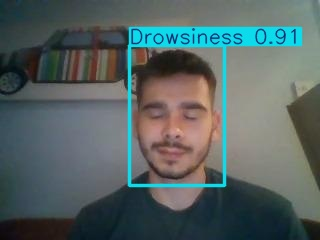

In [17]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob('/content/drive/MyDrive/MiniProject/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[:3]:
    display(IPyImage(filename=img, width=600))
    print("\n")